# 10-Band DSP Audio Equalizer


## Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from dsp_equalizer import (
    DEFAULT_FS,
    BAND_LABELS,
    PRESETS,
    PRESET_DESCRIPTIONS,
    generate_demo_audio,
    process_audio,
    composite_response,
    fft_spectrum,
    compare_methods,
)

fs = DEFAULT_FS
method = "RBJ Parametric EQ"
preset_name = "Smiley / Music"
gains_db = np.array(PRESETS[preset_name], dtype=float)
fir_taps = 1025

print("Selected method:", method)
print("Selected smart preset:", preset_name)
print("Preset description:", PRESET_DESCRIPTIONS[preset_name])
print("Sample rate:", fs)

pd.DataFrame({"Band (Hz)": BAND_LABELS, "Gain (dB)": gains_db})

Selected method: RBJ Parametric EQ
Selected smart preset: Smiley / Music
Preset description: Boosts bass and treble for a wider music sound.
Sample rate: 44100


,Band (Hz),Gain (dB)
0,31.25,7.0
1,62.5,5.0
2,125,2.5
3,250,-1.5
4,500,-4.0
5,1k,-3.0
6,2k,-1.0
7,4k,2.5
8,8k,5.0
9,16k,7.0


## Generate Audio

In [2]:
x = generate_demo_audio(fs=fs, duration=6.0)
t = np.arange(len(x)) / fs

print("Audio duration:", round(len(x) / fs, 2), "seconds")
print("Number of samples:", len(x))

print("Before audio:")
display(Audio(x, rate=fs))

Audio duration: 6.0 seconds
Number of samples: 264600
Before audio:


## Input Waveform

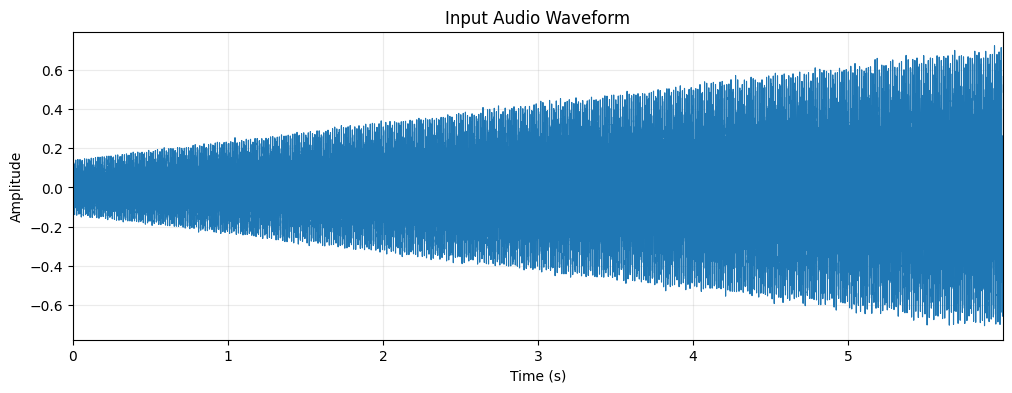

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(t, x, linewidth=0.8)
plt.title("Input Audio Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.25)
plt.xlim(0, t[-1])
plt.show()

## FFT Spectrum Before

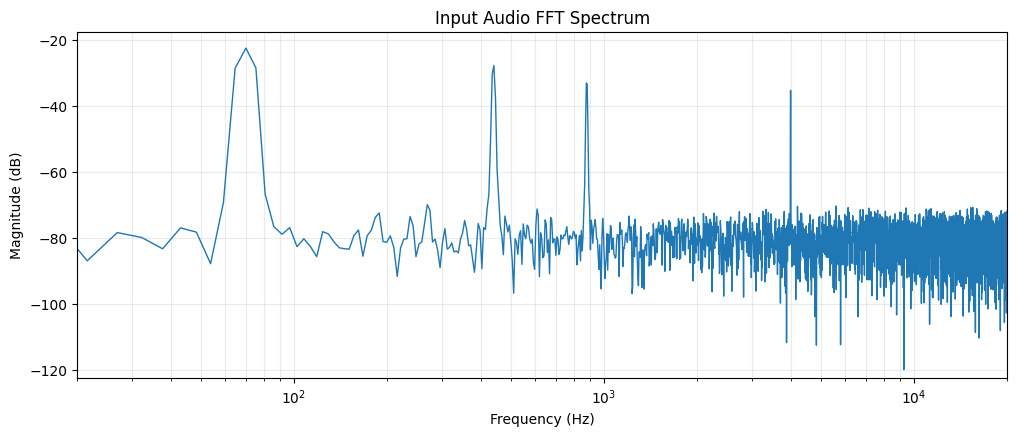

In [4]:
freqs_in, mag_in = fft_spectrum(x, fs)

plt.figure(figsize=(12, 4.5))
plt.semilogx(freqs_in[1:], mag_in[1:], linewidth=1)
plt.title("Input Audio FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(20, 20000)
plt.ylim(np.max(mag_in) - 100, np.max(mag_in) + 5)
plt.grid(True, which="both", alpha=0.25)
plt.show()

## Filter Design Frequency Response

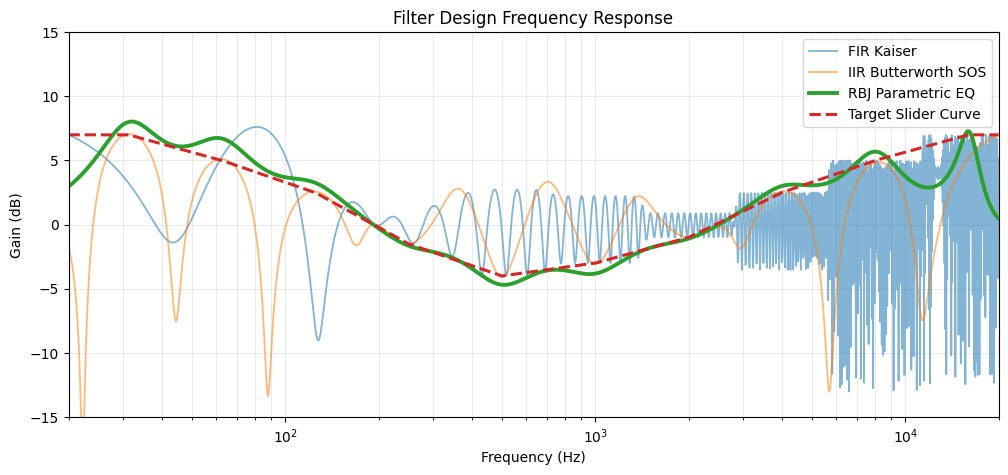

In [5]:
methods = ["FIR Kaiser", "IIR Butterworth SOS", "RBJ Parametric EQ"]

plt.figure(figsize=(12, 5))
for m in methods:
    response = composite_response(m, fs, gains_db, fir_taps=fir_taps)
    lw = 2.8 if m == method else 1.3
    alpha = 1.0 if m == method else 0.55
    plt.semilogx(response["freqs"], response["mag_db"], linewidth=lw, alpha=alpha, label=m)

plt.semilogx(response["freqs"], response["target_db"], linestyle="--", linewidth=2.2, label="Target Slider Curve")
plt.title("Filter Design Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain (dB)")
plt.xlim(20, 20000)
plt.ylim(-15, 15)
plt.grid(True, which="both", alpha=0.25)
plt.legend()
plt.show()

## Apply RBJ Parametric EQ

In [6]:
y, metrics = process_audio(x, fs, gains_db, method, fir_taps=fir_taps)
t_out = np.arange(len(y)) / fs

metrics_df = pd.DataFrame([metrics])
metrics_df.T

,0
method,RBJ Parametric EQ
duration_s,6.0
time_s,0.012109
rtf_x,0.002018
latency_samples,0
latency_ms,0.0
ops_per_sample_est,90
structure,"10 cascaded RBJ peaking biquads, Q=1.414"
input_peak,0.724861
clipping_detected,True


## Clipping Warning and Auto-Normalization

In [7]:
if metrics["clipping_detected"]:
    print("Warning: clipping risk detected. The processed signal exceeded ±1 before normalization.")
elif metrics["normalization_applied"]:
    print("Info: auto-normalization was applied because the output was above the safe peak level of 0.98.")
else:
    print("No clipping risk detected. The output signal is already safe.")

print("Input peak:", round(metrics["input_peak"], 4))
print("Peak before normalization:", round(metrics["max_abs_before_normalization"], 4))
print("Peak after normalization:", round(metrics["max_abs_after_normalization"], 4))
print("Normalization scale factor:", round(metrics["normalization_scale_factor"], 4))

Input peak: 0.7249
Peak before normalization: 1.02
Peak after normalization: 0.98
Normalization scale factor: 0.9608


## Before/After Audio Player

In [8]:
print("Before audio:")
display(Audio(x, rate=fs))

print("After audio:")
display(Audio(y, rate=fs))

Before audio:


After audio:


## Waveform After Equalization

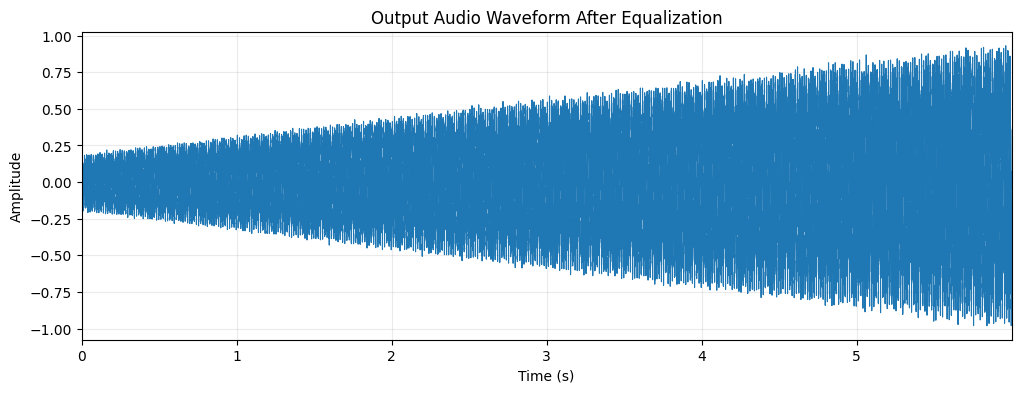

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(t_out, y, linewidth=0.8)
plt.title("Output Audio Waveform After Equalization")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.25)
plt.xlim(0, t_out[-1])
plt.show()

## FFT Spectrum Before vs After 


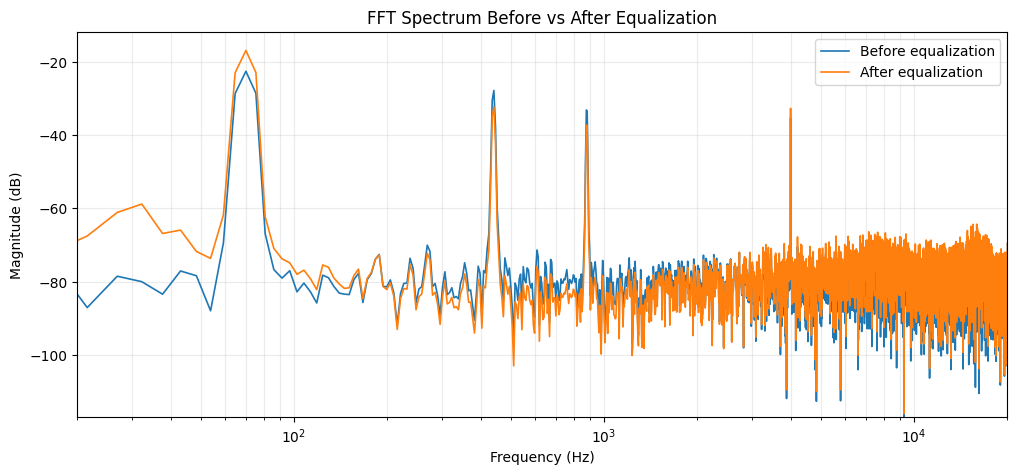

In [13]:
freqs_out, mag_out = fft_spectrum(y, fs)
top = max(np.max(mag_in), np.max(mag_out))

plt.figure(figsize=(12, 5))
plt.semilogx(freqs_in[1:], mag_in[1:], linewidth=1.2, label="Before equalization")
plt.semilogx(freqs_out[1:], mag_out[1:], linewidth=1.2, label="After equalization")
plt.title("FFT Spectrum Before vs After Equalization")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.xlim(20, 20000)
plt.ylim(top - 100, top + 5)
plt.grid(True, which="both", alpha=0.25)
plt.legend()
plt.show()

## Comparison Table

In [11]:
comparison_df = pd.DataFrame(compare_methods(fs, gains_db, fir_taps=fir_taps))
comparison_df

,Method,Filter design,Phase,Latency (ms),Center RMS Error (dB),Estimated Ops/Sample,Best Use
0,FIR Kaiser,Parallel FIR Kaiser-window band-pass filters,Linear phase,11.61,4.526,20520,Good for academic comparison and phase-sensiti...
1,IIR Butterworth SOS,Parallel IIR Butterworth band-pass filters,Non-linear phase,0.00,0.575,390,Strong real-time method with stable SOS implem...
2,RBJ Parametric EQ,Cascaded IIR biquads,Non-linear phase,0.00,0.803,90,Best default for the Streamlit app because it ...
